In [ ]:
!pip install fredapi #Instalamos el paquete de fredapi

In [ ]:
import pandas as pd
from fredapi import Fred
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

API_KEY = "5faade564bd759c41bbcec6d0299e5a5"

fred = Fred(api_key=API_KEY)

series = { #Creamos un diccionario con las variables macroeconómicas a relacionar
    "10Y_yield": "DGS10",        # Rendimientos Bonosdel tesoro a 10 años
    "CPI": "CPIAUCSL",    # Indice de precios al consumidor-Inflación
    "fed_rate": "FEDFUNDS",     # Tasa de fondos federales
    "desempleo": "UNRATE",   # Desempleo en Estados Unidos
    "PIB": "GDP",               # PIB
    "precio_petroleo": "DCOILWTICO"         # Precio del petróleo
}

datos = pd.DataFrame() #Un DataFrame vacio que almacenará 'series'
for name, codigo in series.items(): #Bucle para descargar cada serie y añadirla como columns
  print(f"Descargando {name}...")
  datos[name] = fred.get_series(codigo) #Crea las columnas de df, descarga y coloca los datos

# Resetear índice (fecha)
datos = datos.reset_index() #Convierte el indice (que es la misma fecha) en una columna normal
datos = datos.rename(columns={"index": "fecha"})

# Convertir a datetime (tipo de fecha)
datos["fecha"] = pd.to_datetime(datos["fecha"])

# Ordenar el DataFrame por fecha (de más antiguo a más reciente)
datos = datos.sort_values("fecha")

# Usa la fecha como índice, agrupa por meses y calcula el promedio de cada variable en cada mes
datos = datos.set_index("fecha").resample("M").mean()


# VARIABLES ADICIONALES

# # Calcular la tasa de inflación como variación porcentual mensual del CPI
datos["tasa_inflacion"] = datos["CPI"].pct_change() * 100

# Crecimiento del PIB como variación porcentual
datos["crecimiento_pib"] = datos["PIB"].pct_change() * 100

# Eliminar NaN generados por diferencias
datos = datos.dropna()

print("\nDatos finales:")
print(datos.tail()) #Muestra los datos más recientes

print("\nResumen:")
print(datos.describe())

Descargando 10Y_yield...
Descargando CPI...
Descargando fed_rate...
Descargando desempleo...
Descargando PIB...
Descargando precio_petroleo...

Datos finales:
            10Y_yield      CPI  fed_rate  desempleo        PIB  \
fecha                                                            
2024-07-31   4.248636  313.569      5.33        4.2  29511.664   
2024-10-31   4.095455  315.631      4.83        4.1  29825.182   
2025-01-31   4.629048  318.961      4.33        4.0  30042.113   
2025-04-30   4.279048  320.302      4.33        4.2  30485.729   
2025-07-31   4.391818  322.169      4.33        4.3  31098.027   

            precio_petroleo  tasa_inflacion  crecimiento_pib  
fecha                                                         
2024-07-31        81.800455        0.125808         1.250967  
2024-10-31        71.985000        0.499583         1.062353  
2025-01-31        75.742500        0.768652         0.727342  
2025-04-30        63.536667        0.420428         1.476647  


/tmp/ipykernel_6906/4092287137.py:36: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

/tmp/ipykernel_6906/4092287137.py:42: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

/tmp/ipykernel_6906/4092287137.py:45: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



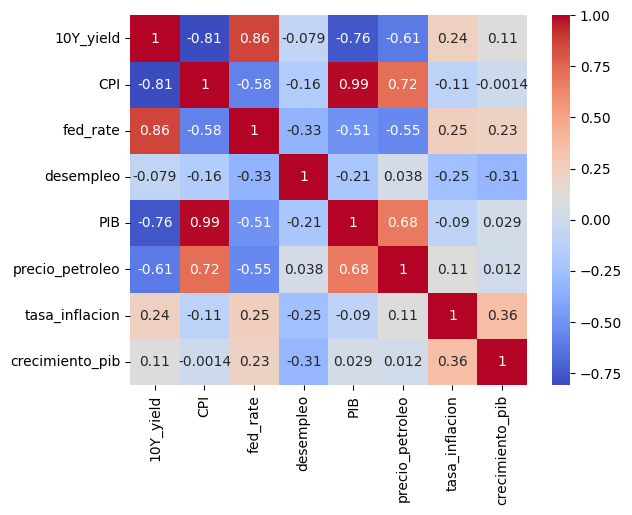

In [ ]:
sns.heatmap(datos.corr(), annot=True, cmap="coolwarm") #Mapa de correlación entre variables
plt.show()

Variables disponibles:
1. 10Y_yield
2. CPI
3. fed_rate
4. desempleo
5. PIB
6. petroleo
7. tasa inflación

Ingresa los números de las variables a comparar separados por coma: 6,7
Descargando petroleo...
Descargando CPI...


/tmp/ipykernel_6906/269296771.py:50: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



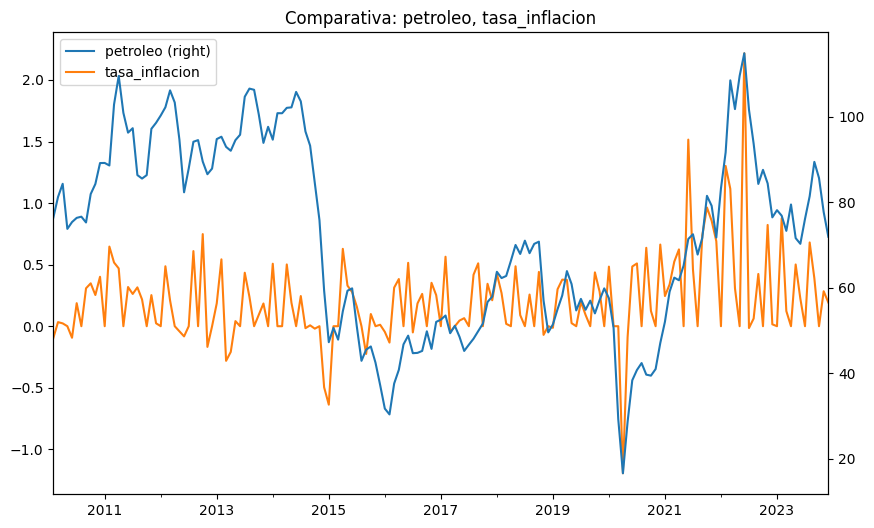

In [ ]:
 class AnalizadorMacro:
    def __init__(self, api_key):
        self.fred = Fred(api_key=api_key) #inicializar la conexión con la API de FRED
        self.series_disponibles = {
            "1": ("10Y_yield", "DGS10"), #Definimos número, nombre y código en FRED para cada variable
            "2": ("CPI", "CPIAUCSL"),
            "3": ("fed_rate", "FEDFUNDS"),
            "4": ("desempleo", "UNRATE"),
            "5": ("PIB", "GDP"),
            "6": ("petroleo", "DCOILWTICO"),
            "7": ("tasa inflación", "tasa_inflacion_calculated")#Variable que calculamos anteriormente
        }

    def obtener_datos(self, seleccionados, inicio, fin): #Saca datos de acuerdo con la selección del usuario
        df_final = pd.DataFrame() #Nuevamente un DataFrame vacío para almacenar los datos
        series_to_fetch = {} #Diccionario temporal con las series que se van a decargar
        needs_cpi_for_inflation = False #

        for sel_key in seleccionados: #Recorremos las variables seleccionadas por el usuario con una LIST COMPREHENSION
            if sel_key in self.series_disponibles:
                nombre, codigo = self.series_disponibles[sel_key]

                if codigo == "tasa_inflacion_calculated": #En caso de que el usuario pida el dato de tasa de inflación
                    needs_cpi_for_inflation = True
                else:
                    series_to_fetch[nombre] = codigo
            else:
                print(f"Advertencia: {sel_key} no es válido")


        if needs_cpi_for_inflation:
            series_to_fetch["CPI"] = "CPIAUCSL" #Si necesitamos inflación añadimos CPI (Consumer Price Index) para calcularla

       #Descargan los datos
        for nombre, codigo in series_to_fetch.items():
            print(f"Descargando {nombre}...")
            serie = self.fred.get_series(
                codigo,
                observation_start=inicio,
                observation_end=fin
            )
            df_final[nombre] = serie #Como resultado guardamos cada serie como columna en el DataFrame

        #Limpieza y ajuste de temporalidad
        df_final.index = pd.to_datetime(df_final.index)  # Convertimos índice a tipo fecha
        df_final = df_final.resample("ME").mean() # Reagrupamos por mes (fin de mes) y sacamos promedio

        #Inflación mensual como variación porcentual del CPI
        if needs_cpi_for_inflation and "CPI" in df_final.columns:
            df_final["tasa_inflacion"] = df_final["CPI"].pct_change() * 100

            # eliminar CPI si no fue solicitado explícitamente
            if "2" not in seleccionados:
                df_final = df_final.drop(columns=["CPI"])

        #Crecimiento del PIB como variacion porcentual
        if "PIB" in df_final.columns:
            df_final["crecimiento_pib"] = df_final["PIB"].pct_change() * 100

        #Limpieza Final NAN
        df_final = df_final.dropna()
        return df_final

# LÓGICA DE INTERACCIÓN

API_KEY = "5faade564bd759c41bbcec6d0299e5a5"
analizador = AnalizadorMacro(API_KEY)

# 1. Mostrar opciones al usuario
print("Variables disponibles:")
for k, v in analizador.series_disponibles.items():
    print(f"{k}. {v[0]}") # Muestra al usuario: número de opción y nombre de la variable

# 2. Entrada del usuario (ejemplo: "1, 4")
entrada = input("\nIngresa los números de las variables a comparar separados por coma: ")
seleccion = [x.strip() for x in entrada.split(",")] #La lista limbia las variables, quita espacios, separa con comas

# 3. Definir fechas
fecha_inicio = "2010-01-01"
fecha_fin = "2024-01-01"

# 4. Ejecutar proceso
datos = analizador.obtener_datos(seleccion, fecha_inicio, fecha_fin)

# 5. Visualización dinámica
if not datos.empty:
    datos.plot(figsize=(10, 6), secondary_y=[datos.columns[0]] if len(datos.columns) > 1 else False) #Evita que arroje gráficas con escalas muy diferentes
    plt.title(f"Comparativa: {', '.join(datos.columns)}") #.join une los nombres de las columnas
    plt.show()
else:
    print("No se encontraron datos para esa selección o rango.")

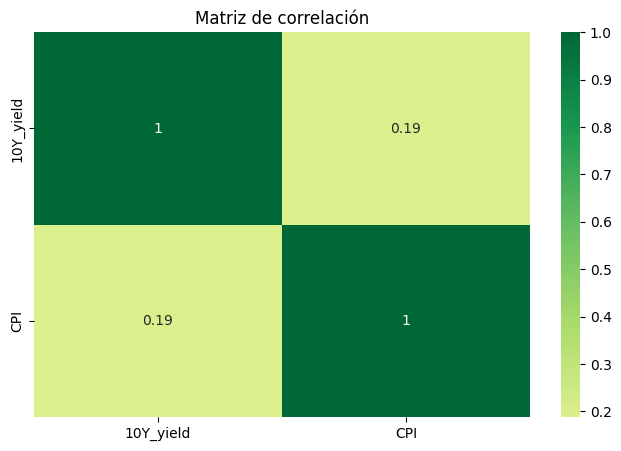

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(datos.corr(), annot= True, cmap= "RdYlGn", center=0) #Escala de colores en 0(sin correlacion)
plt.title("Matriz de correlación")
plt.show()

In [ ]:
archivo = "/China Holdings of U.S. Treasuries.xlsx" #Guía al archivo excel que contiene todos los datos relevsntes de China
tesoro = pd.read_excel(archivo) #Carga el excel en un DataFrame que llamamos tesoro

print(tesoro.head())

           Country  2026-02  2026-01  2025-12  2025-11  2025-10  2025-09  \
0            Japan   1239.3   1225.3   1185.5   1202.7   1200.0   1189.3   
1   United Kingdom    897.3    879.7    863.1    879.8    875.4    862.1   
2  China, Mainland    693.3    694.4    683.5    683.9    687.7    699.2   
3          Belgium    454.7    451.0    477.3    481.0    465.5    463.6   
4           Canada    446.3    395.8    468.2    472.4    419.4    476.0   

   2025-08  2025-07  2025-06  2025-05  2025-04  2025-03  2025-02  
0   1180.4   1151.8   1147.9   1135.0   1134.5   1130.8   1125.9  
1    901.4    896.0    855.7    809.4    807.7    779.3    750.3  
2    699.7    695.6    731.4    732.7    743.6    765.4    784.3  
3    451.1    425.4    430.3    415.5    411.1    402.1    394.7  
4    443.8    381.6    438.7    430.1    368.4    426.2    406.1  


/tmp/ipykernel_6906/631065898.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datos = datos.resample("M").mean()


<Axes: >

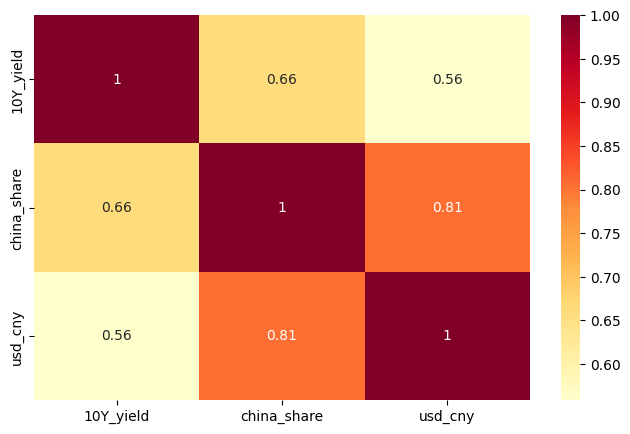

In [ ]:
series = {
    "10Y_yield": "DGS10", #Rendimientos de bonos del tesoro a 10 años
    "usd_cny": "DEXCHUS" #Tipo de cambio USD/CNY
}

datos = pd.DataFrame()

for name, code in series.items():
    datos[name] = fred.get_series(code) #Descarga cada serie y la guarda como columna

# Convertir índice a datetime
datos.index = pd.to_datetime(datos.index)

# Pasar a mensual
datos = datos.resample("M").mean()

df = pd.read_excel("/China Holdings of U.S. Treasuries.xlsx")

# Separamos solo a China
china = df[df["Country"].str.contains("China")]
china_series = china.drop(columns="Country").iloc[0] #i.loc[0] Selecciona la primera fila del DataFrame
#Devuelve una serie con los valores de esa fila ('china')

# Total de las tenencias de los otros paises
total = df.drop(columns="Country").sum()

# % participación de China sobre el global
share = (china_series / total) * 100

china_df = pd.DataFrame({ # Creamos DataFrame con fechas y participación de China
    "fecha": pd.to_datetime(share.index), #indice a fechas
    "china_share": share.values #Valores de participación
})

# Poner la fecha como  índice, pasamos a frecuencia mensual (fin de mes)
china_df = china_df.set_index("fecha")

# Arreglamos la temporlidad
china_df.index = china_df.index.to_period("M").to_timestamp("M")

#Unimos las series de FRED con la participación de China
datos = datos.join(china_df, how="inner") #Une 'datos' con 'china_df' pero solo mantiene las fechas que existen en ambos

datos["cambio_yield"] = datos["10Y_yield"].diff() #.diff Calcula el cambio entre un dato y el anterior
datos["cambio_china"] = datos["china_share"].diff() #Cambio rendimineto de bonos y particpación China

#Limpieza final
datos = datos.dropna()


plt.figure(figsize=(8,5))
sns.heatmap(
    datos[["10Y_yield", "china_share", "usd_cny"]].corr(),
    annot=True,
    cmap="YlOrRd"
)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure() #Inicializamos una figura vacía de Plotly para luego llenarla de datos

#Rendimientos de bonos a 10 años
fig.add_scatter(x=datos_analisis.index, y=datos_analisis["10Y_yield"], name="Yield")

# Participación de China en bonos del Tesoro (%)
fig.add_scatter(x=datos_analisis.index, y=datos_analisis["china_share"], name="China %", yaxis="y2")

# Normalizamos el tipo de cambio USD/CNY respecto al primer valor
datos_analisis["usd_cny_norm"] = datos_analisis["usd_cny"] / datos_analisis["usd_cny"].iloc[0]

fig.add_scatter(x=datos_analisis.index, y=datos_analisis["usd_cny_norm"], name="USD/CNY (norm)")

fig.update_layout(
    yaxis=dict(title="Yield"), #Eje Y
    yaxis2=dict(title="China %", overlaying="y", side="right"),# Eje Y secundario (derecha)
    title="Yield, China y Tipo de Cambio"
)

fig.show()